# Seasonal Sentiment and Tourism Volume (NYC) — Simplified Portfolio

## Business question
Do complaints about specific aspects (e.g. crowding, wait time, noise) tend to be higher in **busier months** — when NYC visitor volume is higher? This notebook explores that question in a simple, descriptive way.

## What this analysis does (and does not)
- **Does:** Compares aspect-level negative sentiment in both **high-vs-low months** (top/bottom 30%) and a **3-bin view** (low/mid/high) so all months are represented. No advanced statistics — just proportions and bar charts.
- **Does not:** Claim that volume *causes* sentiment; we only describe co-movement. No tourism-season labels — we work at **month level** and define busy/quiet by volume percentiles across months.

## Two aspect groups
1. **Hypothesis-related:** crowding, wait time, noise level (pressure aspects we care about most).
2. **High-support (top-5 by mentions):** the five most frequently mentioned aspects (excluding tours and entertainment) as a robustness check.

## 1) Setup and data sources

We set the project root and paths to the ABSA (Tripadvisor aspect–sentiment) and BTS volume datasets. No season mapping — we keep **month** as the time unit.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)


def find_project_root():
    """Locate project root by walking up until .projectroot is found."""
    current = Path.cwd()
    for _ in range(12):
        if (current / ".projectroot").exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError("Could not find project root (.projectroot marker not found).")


project_root = find_project_root()
absa_path = project_root / "data" / "silver" / "tripadvisor" / "staged_primary" / "tripadvisor_nyc_absa_llm_full_5000_staged.parquet"
volume_path = project_root / "data" / "silver" / "volume_data" / "staged" / "bts_volume_staged.parquet"

print(f"Project root: {project_root}")
print(f"ABSA file exists: {absa_path.exists()}")
print(f"Volume file exists: {volume_path.exists()}")

Project root: /Users/kristinakogan/code/TinaKgn/tourism_data_project
ABSA file exists: True
Volume file exists: True


**Data sources:** ABSA = Tripadvisor reviews with LLM-extracted aspect–sentiment; BTS = NYC visitor volume. Time span in the staged data: 2016–2018 and 2022–2023 (pre/post COVID gap).

## 2) Build analysis table at month level

We expand ABSA to one row per (aspect, year, month) with `total_mentions`, `negative_mentions`, and `prop_negative`. We merge NYC BTS volume by (year, month). Later we will label months as "busy" or "quiet" using volume percentiles.

In [2]:
df_absa = pd.read_parquet(absa_path)
df_volume = pd.read_parquet(volume_path)

ASPECTS_COL = "llm_aspects" if "llm_aspects" in df_absa.columns else "absa_aspects"

records = []
for _, r in df_absa.iterrows():
    raw = r.get(ASPECTS_COL)
    if isinstance(raw, str):
        try:
            raw = json.loads(raw)
        except Exception:
            continue
    if not isinstance(raw, dict):
        continue
    for aspect, payload in raw.items():
        if not isinstance(payload, dict):
            continue
        sentiment = str(payload.get("sentiment", "")).strip().lower().capitalize()
        if sentiment not in {"Negative", "Neutral", "Positive"}:
            continue
        records.append({
            "year": int(r["rvw_year_pr"]),
            "month": int(r["rvw_month_pr"]),
            "aspect": aspect,
            "sentiment": sentiment,
        })

df_long = pd.DataFrame(records)
aspect_ym = (
    df_long.groupby(["aspect", "year", "month"], observed=True)
    .agg(
        total_mentions=("sentiment", "size"),
        negative_mentions=("sentiment", lambda s: (s == "Negative").sum()),
    )
    .reset_index()
)
aspect_ym["prop_negative"] = aspect_ym["negative_mentions"] / aspect_ym["total_mentions"]

vol_nyc = df_volume[df_volume["market_city"] == "New York City"].copy()
vol_nyc["year"] = vol_nyc["year"].astype(int)
vol_nyc["month"] = vol_nyc["month"].astype(int)
vol_ym = vol_nyc.groupby(["year", "month"]).agg(all_vol_raw=("all_vol_raw", "sum")).reset_index()

analysis_df = aspect_ym.merge(vol_ym, on=["year", "month"], how="inner")
print(f"Analysis rows: {len(analysis_df):,}")
print(f"Aspects: {analysis_df['aspect'].nunique()}")
analysis_df.head(20)

Analysis rows: 730
Aspects: 15


,aspect,year,month,total_mentions,negative_mentions,prop_negative,all_vol_raw
0,accommodation quality,2016,1,68,4,0.058824,9189965.0
1,accommodation quality,2016,2,68,4,0.058824,8766376.0
2,accommodation quality,2016,3,69,2,0.028986,10806272.0
3,accommodation quality,2016,4,69,6,0.086957,10790028.0
4,accommodation quality,2016,5,69,5,0.072464,11558992.0
5,accommodation quality,2016,6,69,6,0.086957,11779281.0
6,accommodation quality,2016,7,69,3,0.043478,12414669.0
7,accommodation quality,2016,8,67,2,0.029851,12506166.0
8,accommodation quality,2016,9,68,2,0.029412,10789002.0
9,accommodation quality,2016,10,69,2,0.028986,10988147.0


Each row is one (aspect, year, month) with sentiment counts and city volume. We work at month granularity and will define busy/quiet by volume percentiles over all months.

## 3) Aspect selection and support overview

We define two groups: **hypothesis** (crowding, wait time, noise level) and **top-5 frequency** — the five aspects with the most total mentions, excluding `tours` and `entertainment`. Under-represented aspects are more prone to noise; high-frequency aspects act as a stability check.

In [3]:
HYPOTHESIS_ASPECTS = {"crowding", "wait time", "noise level"}
EXCLUDE_ASPECTS = {"tours", "entertainment"}

support = (
    analysis_df.groupby("aspect")
    .agg(total_mentions=("total_mentions", "sum"), n_months=("year", "count"))
    .reset_index()
)
support["group"] = support["aspect"].apply(
    lambda a: "hypothesis" if a in HYPOTHESIS_ASPECTS else "other"
)
candidates = support[~support["aspect"].isin(EXCLUDE_ASPECTS)].copy()
top5 = candidates.nlargest(5, "total_mentions")["aspect"].tolist()
# Label as top5_frequency only if not already hypothesis (so hypothesis aspects stay in hypothesis group)
for a in top5:
    if support.loc[support["aspect"] == a, "group"].iloc[0] != "hypothesis":
        support.loc[support["aspect"] == a, "group"] = "top5_frequency"
selected = support[support["group"].isin(["hypothesis", "top5_frequency"])].copy()
selected = selected.sort_values(["group", "total_mentions"], ascending=[True, False])
print("Selected aspects (hypothesis + top-5 by mentions, excluding tours & entertainment):")
display(selected)

Selected aspects (hypothesis + top-5 by mentions, excluding tours & entertainment):


,aspect,total_mentions,n_months,group
8,noise level,756,49,hypothesis
14,wait time,252,48,hypothesis
4,crowding,194,49,hypothesis
0,accommodation quality,3306,49,top5_frequency
13,value for money,3245,49,top5_frequency
11,staff friendliness,3206,49,top5_frequency
10,service quality,2876,49,top5_frequency
7,location,2796,49,top5_frequency


Aspects with few months or few mentions are more prone to false positives; we will still report them but note limited support where relevant.

## 4) Volume-bin contrasts (high/low and low/mid/high)

We label each month as **HIGH** (top 30% of months by city volume), **LOW** (bottom 30%), or **MID** (middle 40%). For each selected aspect we compute:
- overall negative proportion using **all months**
- high-vs-low contrast (for direct extreme comparison)
- low/mid/high proportions (to keep middle months in view)

This is descriptive co-movement, not causal inference.

In [4]:
# Volume percentiles over (year, month) — one value per month
vol_by_month = analysis_df[["year", "month", "all_vol_raw"]].drop_duplicates()
p70 = vol_by_month["all_vol_raw"].quantile(0.70)
p30 = vol_by_month["all_vol_raw"].quantile(0.30)

# Label all months into 3 bins (LOW / MID / HIGH)
analysis_df["volume_group"] = np.where(
    analysis_df["all_vol_raw"] >= p70,
    "HIGH",
    np.where(analysis_df["all_vol_raw"] <= p30, "LOW", "MID"),
)

selected_aspects = selected["aspect"].tolist()
contrast_rows = []
bins3_rows = []

for aspect in selected_aspects:
    adf_all = analysis_df[analysis_df["aspect"] == aspect].copy()
    if adf_all.empty:
        continue

    # Overall negativity uses ALL months (not only high/low subset)
    overall_mentions = adf_all["total_mentions"].sum()
    overall_neg = adf_all["negative_mentions"].sum()
    overall_prop = overall_neg / overall_mentions if overall_mentions else 0

    high_df = adf_all[adf_all["volume_group"] == "HIGH"]
    mid_df = adf_all[adf_all["volume_group"] == "MID"]
    low_df = adf_all[adf_all["volume_group"] == "LOW"]

    high_n = len(high_df)
    mid_n = len(mid_df)
    low_n = len(low_df)

    h_neg = high_df["negative_mentions"].sum()
    h_tot = high_df["total_mentions"].sum()
    m_neg = mid_df["negative_mentions"].sum()
    m_tot = mid_df["total_mentions"].sum()
    l_neg = low_df["negative_mentions"].sum()
    l_tot = low_df["total_mentions"].sum()

    high_prop = h_neg / h_tot if h_tot else 0
    mid_prop = m_neg / m_tot if m_tot else 0
    low_prop = l_neg / l_tot if l_tot else 0

    grp = selected.loc[selected["aspect"] == aspect, "group"].iloc[0]

    # Keep high-vs-low comparison with minimum support in each extreme bin
    if high_n >= 3 and low_n >= 3:
        contrast_rows.append({
            "aspect": aspect,
            "group": grp,
            "overall_prop_neg": overall_prop,
            "high_prop_neg": high_prop,
            "low_prop_neg": low_prop,
            "delta_high_low_pp": (high_prop - low_prop) * 100,
            "total_mentions": int(overall_mentions),
            "high_n_months": high_n,
            "low_n_months": low_n,
        })

    # 3-bin view uses all months and reports LOW / MID / HIGH side by side
    if high_n >= 3 and mid_n >= 3 and low_n >= 3:
        bins3_rows.append({
            "aspect": aspect,
            "group": grp,
            "overall_prop_neg": overall_prop,
            "low_prop_neg": low_prop,
            "mid_prop_neg": mid_prop,
            "high_prop_neg": high_prop,
            "delta_high_low_pp": (high_prop - low_prop) * 100,
            "total_mentions": int(overall_mentions),
            "low_n_months": low_n,
            "mid_n_months": mid_n,
            "high_n_months": high_n,
        })

contrast_df = pd.DataFrame(contrast_rows)
bins3_df = pd.DataFrame(bins3_rows)

print("A month is 'busy' (HIGH) if city volume is in the top 30% of months; 'quiet' (LOW) = bottom 30%; middle months are MID.")
print("\nHigh-vs-low contrast table:")
display(contrast_df)
print("\n3-bin (LOW/MID/HIGH) table:")
display(bins3_df)

A month is 'busy' (HIGH) if city volume is in the top 30% of months; 'quiet' (LOW) = bottom 30%; middle months are MID.

High-vs-low contrast table:


,aspect,group,overall_prop_neg,high_prop_neg,low_prop_neg,delta_high_low_pp,total_mentions,high_n_months,low_n_months
0,noise level,hypothesis,0.250000,0.246696,0.246914,-0.021755,756,15,15
1,wait time,hypothesis,0.357143,0.290698,0.394366,-10.366852,252,15,15
2,crowding,hypothesis,0.371134,0.490566,0.271186,21.937960,194,15,15
3,accommodation quality,top5_frequency,0.061101,0.057426,0.053360,0.406606,3306,15,15
4,value for money,top5_frequency,0.059784,0.055781,0.056112,-0.033129,3245,15,15
5,staff friendliness,top5_frequency,0.025265,0.020408,0.023422,-0.301343,3206,15,15
6,service quality,top5_frequency,0.048679,0.050847,0.038636,1.221109,2876,15,15
7,location,top5_frequency,0.016810,0.012644,0.015276,-0.263247,2796,15,15



3-bin (LOW/MID/HIGH) table:


,aspect,group,overall_prop_neg,low_prop_neg,mid_prop_neg,high_prop_neg,delta_high_low_pp,total_mentions,low_n_months,mid_n_months,high_n_months
0,noise level,hypothesis,0.250000,0.246914,0.255245,0.246696,-0.021755,756,15,19,15
1,wait time,hypothesis,0.357143,0.394366,0.389474,0.290698,-10.366852,252,15,18,15
2,crowding,hypothesis,0.371134,0.271186,0.365854,0.490566,21.937960,194,15,19,15
3,accommodation quality,top5_frequency,0.061101,0.053360,0.070093,0.057426,0.406606,3306,15,19,15
4,value for money,top5_frequency,0.059784,0.056112,0.065821,0.055781,-0.033129,3245,15,19,15
5,staff friendliness,top5_frequency,0.025265,0.023422,0.030547,0.020408,-0.301343,3206,15,19,15
6,service quality,top5_frequency,0.048679,0.038636,0.054905,0.050847,1.221109,2876,15,19,15
7,location,top5_frequency,0.016810,0.015276,0.021395,0.012644,-0.263247,2796,15,19,15


Positive `delta_high_low_pp` means negativity is higher in busier months than in quieter months (descriptive only).
The 3-bin table (`LOW`, `MID`, `HIGH`) uses all months so the middle period is retained in the analysis.

## 5) Visual summaries: high/low and 3-bin views

First chart: grouped bars for high-vs-low negativity (extreme contrast).
Second chart: grouped bars for low/mid/high negativity so all months are represented.

/var/folders/2l/8rtkcb8x1lq1l5hrrsf7kghw0000gn/T/ipykernel_19207/1254903660.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")
/var/folders/2l/8rtkcb8x1lq1l5hrrsf7kghw0000gn/T/ipykernel_19207/1254903660.py:74: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")


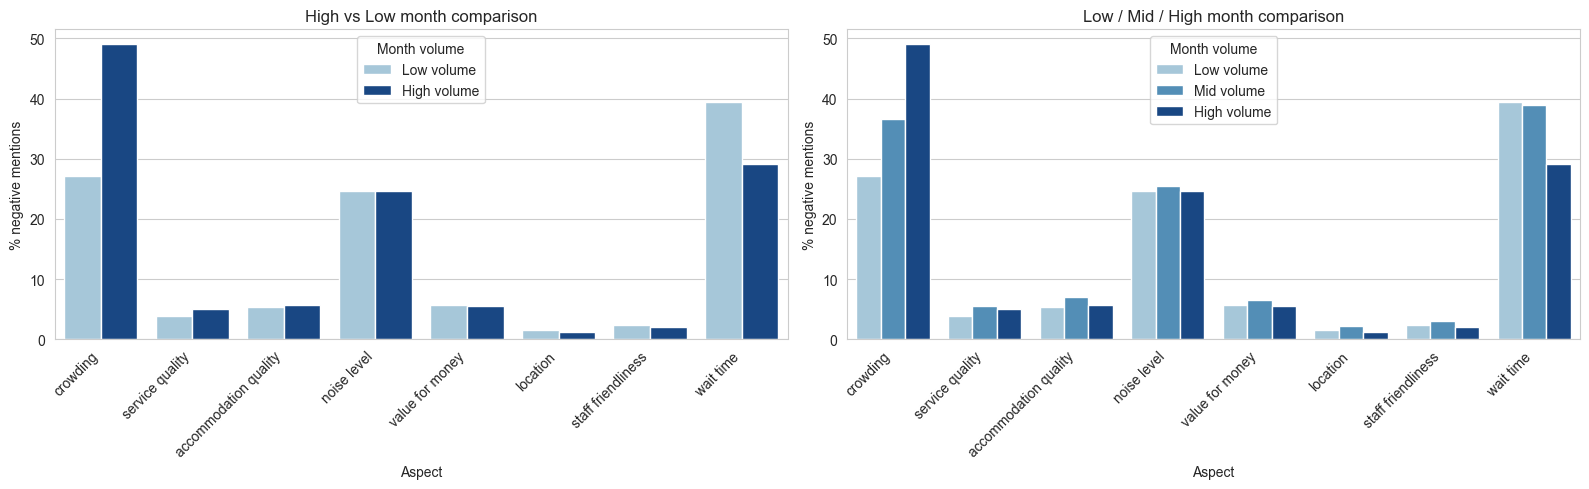

In [5]:
# Consistent palette across both charts: LOW (light blue), MID (mid blue), HIGH (dark blue)
volume_palette = {
    "Low volume": "#9ecae1",
    "Mid volume": "#4292c6",
    "High volume": "#084594",
}

# Chart 1: High vs Low (extreme contrast)
plot_df = contrast_df.copy()
plot_df["high_pct"] = plot_df["high_prop_neg"] * 100
plot_df["low_pct"] = plot_df["low_prop_neg"] * 100
melted_hl = plot_df.melt(
    id_vars=["aspect", "group"],
    value_vars=["high_pct", "low_pct"],
    var_name="volume_group",
    value_name="pct_negative",
)
melted_hl["volume_group"] = melted_hl["volume_group"].map({
    "high_pct": "High volume",
    "low_pct": "Low volume",
})
order_hl = plot_df.sort_values("delta_high_low_pp", ascending=False)["aspect"].tolist()
melted_hl["aspect"] = pd.Categorical(melted_hl["aspect"], categories=order_hl, ordered=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(
    data=melted_hl,
    x="aspect",
    y="pct_negative",
    hue="volume_group",
    hue_order=["Low volume", "High volume"],
    palette=volume_palette,
    ax=axes[0],
    order=order_hl,
 )
axes[0].set_title("High vs Low month comparison")
axes[0].set_ylabel("% negative mentions")
axes[0].set_xlabel("Aspect")
axes[0].legend(title="Month volume")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha="right")

# Chart 2: Low / Mid / High (all months used)
plot3 = bins3_df.copy()
plot3["low_pct"] = plot3["low_prop_neg"] * 100
plot3["mid_pct"] = plot3["mid_prop_neg"] * 100
plot3["high_pct"] = plot3["high_prop_neg"] * 100
melted_3 = plot3.melt(
    id_vars=["aspect", "group"],
    value_vars=["low_pct", "mid_pct", "high_pct"],
    var_name="volume_group",
    value_name="pct_negative",
)
melted_3["volume_group"] = melted_3["volume_group"].map({
    "low_pct": "Low volume",
    "mid_pct": "Mid volume",
    "high_pct": "High volume",
})
order_3 = plot3.sort_values("delta_high_low_pp", ascending=False)["aspect"].tolist()
melted_3["aspect"] = pd.Categorical(melted_3["aspect"], categories=order_3, ordered=True)
sns.barplot(
    data=melted_3,
    x="aspect",
    y="pct_negative",
    hue="volume_group",
    hue_order=["Low volume", "Mid volume", "High volume"],
    palette=volume_palette,
    ax=axes[1],
    order=order_3,
 )
axes[1].set_title("Low / Mid / High month comparison")
axes[1].set_ylabel("% negative mentions")
axes[1].set_xlabel("Aspect")
axes[1].legend(title="Month volume")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Appendix to 5): 2-bin view for all available aspects

This appendix keeps the same HIGH vs LOW month definition as above, but expands the comparison to every aspect with at least 3 HIGH months and 3 LOW months in the available data.

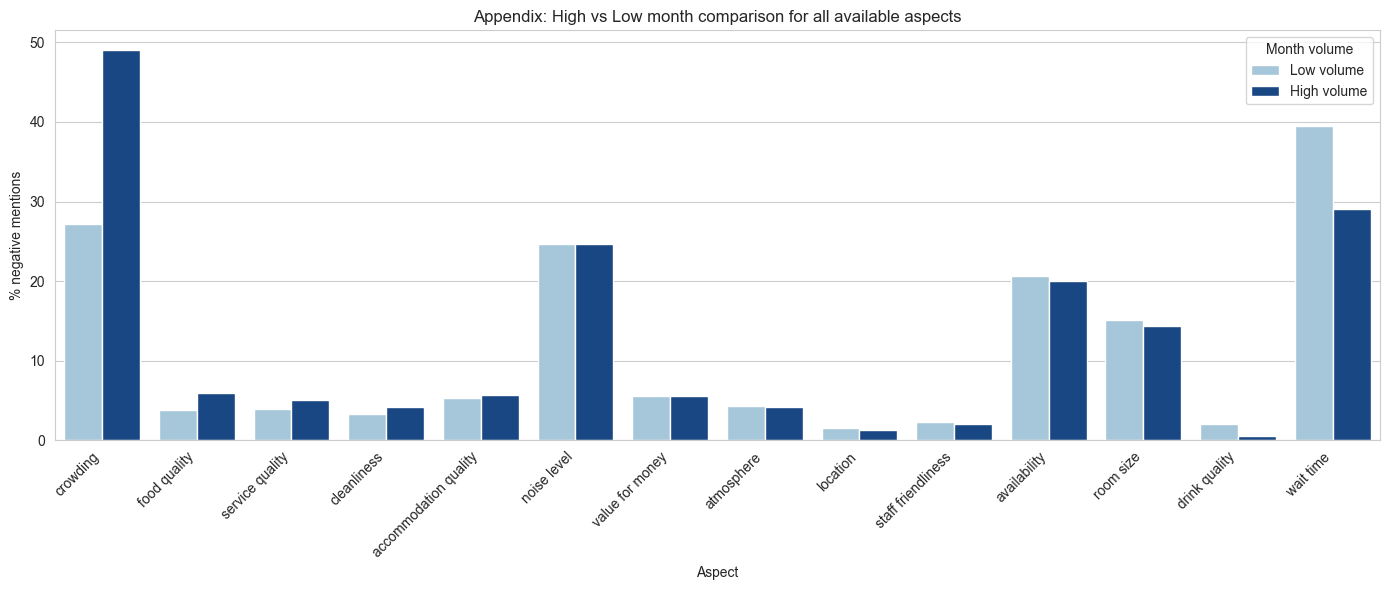

,aspect,high_prop_neg,low_prop_neg,delta_high_low_pp,total_mentions,high_n_months,low_n_months
0,crowding,0.490566,0.271186,21.937960,194,15,15
1,food quality,0.058824,0.038585,2.023832,926,15,15
2,service quality,0.050847,0.038636,1.221109,2876,15,15
3,cleanliness,0.041667,0.033577,0.809002,2230,15,15
4,accommodation quality,0.057426,0.053360,0.406606,3306,15,15
5,noise level,0.246696,0.246914,-0.021755,756,15,15
6,value for money,0.055781,0.056112,-0.033129,3245,15,15
7,atmosphere,0.041369,0.043115,-0.174597,2296,15,15
8,location,0.012644,0.015276,-0.263247,2796,15,15
9,staff friendliness,0.020408,0.023422,-0.301343,3206,15,15


In [8]:
all_aspects_rows = []

for aspect in sorted(a for a in analysis_df["aspect"].dropna().unique() if a != "tours"):
    adf_all = analysis_df[analysis_df["aspect"] == aspect].copy()
    if adf_all.empty:
        continue

    high_df = adf_all[adf_all["volume_group"] == "HIGH"]
    low_df = adf_all[adf_all["volume_group"] == "LOW"]

    high_n = len(high_df)
    low_n = len(low_df)
    if high_n < 3 or low_n < 3:
        continue

    h_neg = high_df["negative_mentions"].sum()
    h_tot = high_df["total_mentions"].sum()
    l_neg = low_df["negative_mentions"].sum()
    l_tot = low_df["total_mentions"].sum()

    high_prop = h_neg / h_tot if h_tot else 0
    low_prop = l_neg / l_tot if l_tot else 0

    all_aspects_rows.append({
        "aspect": aspect,
        "high_prop_neg": high_prop,
        "low_prop_neg": low_prop,
        "delta_high_low_pp": (high_prop - low_prop) * 100,
        "total_mentions": int(adf_all["total_mentions"].sum()),
        "high_n_months": high_n,
        "low_n_months": low_n,
    })

all_aspects_contrast_df = pd.DataFrame(all_aspects_rows)

if all_aspects_contrast_df.empty:
    print("No aspects met the minimum support threshold for both HIGH and LOW month bins.")
else:
    all_aspects_contrast_df = all_aspects_contrast_df.sort_values(
        ["delta_high_low_pp", "total_mentions"], ascending=[False, False]
    ).reset_index(drop=True)

    all_aspects_plot_df = all_aspects_contrast_df.copy()
    all_aspects_plot_df["high_pct"] = all_aspects_plot_df["high_prop_neg"] * 100
    all_aspects_plot_df["low_pct"] = all_aspects_plot_df["low_prop_neg"] * 100

    all_aspects_melted = all_aspects_plot_df.melt(
        id_vars=["aspect"],
        value_vars=["low_pct", "high_pct"],
        var_name="volume_group",
        value_name="pct_negative",
    )
    all_aspects_melted["volume_group"] = all_aspects_melted["volume_group"].map({
        "low_pct": "Low volume",
        "high_pct": "High volume",
    })

    all_aspects_order = all_aspects_plot_df["aspect"].tolist()
    all_aspects_melted["aspect"] = pd.Categorical(
        all_aspects_melted["aspect"], categories=all_aspects_order, ordered=True
    )

    plt.figure(figsize=(max(14, len(all_aspects_order) * 0.6), 6))
    sns.barplot(
        data=all_aspects_melted,
        x="aspect",
        y="pct_negative",
        hue="volume_group",
        hue_order=["Low volume", "High volume"],
        palette=volume_palette,
        order=all_aspects_order,
    )
    plt.title("Appendix: High vs Low month comparison for all available aspects")
    plt.ylabel("% negative mentions")
    plt.xlabel("Aspect")
    plt.legend(title="Month volume")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    display(all_aspects_contrast_df)

## 6) Copy-ready narratives

Below: per-aspect one-liners and two short narrative blocks (hypothesis aspects and top-5 frequency), plus limitations.

In [7]:
def aspect_summary(row):
    """Generate a short templated summary for one aspect."""
    a = row["aspect"]
    x = row["total_mentions"]
    y = row["overall_prop_neg"] * 100
    hi = row["high_prop_neg"] * 100
    lo = row["low_prop_neg"] * 100
    d = row["delta_high_low_pp"]
    return (
        f"{a!r} appears in ~{x:,} mentions. Overall, about {y:.1f}% are negative. "
        f"In the busiest 30% of months (by city volume), this is {hi:.1f}%, "
        f"vs {lo:.1f}% in the quietest 30% (difference {d:+.1f} pp)."
    )

for _, row in contrast_df.iterrows():
    print(aspect_summary(row))
    print()

'noise level' appears in ~756 mentions. Overall, about 25.0% are negative. In the busiest 30% of months (by city volume), this is 24.7%, vs 24.7% in the quietest 30% (difference -0.0 pp).

'wait time' appears in ~252 mentions. Overall, about 35.7% are negative. In the busiest 30% of months (by city volume), this is 29.1%, vs 39.4% in the quietest 30% (difference -10.4 pp).

'crowding' appears in ~194 mentions. Overall, about 37.1% are negative. In the busiest 30% of months (by city volume), this is 49.1%, vs 27.1% in the quietest 30% (difference +21.9 pp).

'accommodation quality' appears in ~3,306 mentions. Overall, about 6.1% are negative. In the busiest 30% of months (by city volume), this is 5.7%, vs 5.3% in the quietest 30% (difference +0.4 pp).

'value for money' appears in ~3,245 mentions. Overall, about 6.0% are negative. In the busiest 30% of months (by city volume), this is 5.6%, vs 5.6% in the quietest 30% (difference -0.0 pp).

'staff friendliness' appears in ~3,206 mention

**Hypothesis-group narrative**  
For the pressure aspects we care about most — crowding, wait time, and noise level — we compared negative sentiment in the busiest 30% of months (by NYC visitor volume) vs the quietest 30%. Where sample size is low (e.g. few months or few mentions), the estimates are underpowered and should be interpreted with caution. Where both high- and low-volume groups have enough months and mentions, a positive difference (more negativity in busier months) is consistent with the idea that these complaints co-move with volume; we do not claim causation.

**Top-5 frequency narrative**  
The five most frequently mentioned aspects (excluding tours and entertainment) were used as a robustness check. If their high-vs-low volume negativity pattern is similar to the hypothesis aspects, it supports that the signal is not driven only by a few rare aspects. Results are descriptive and should be read alongside the bar chart and the per-aspect summaries above.

**Limitations and next steps**  
- Data span includes a pre/post COVID gap (2016–2018 and 2022–2023); seasonal patterns may differ across those periods.  
- Limited time span and no control for other confounders (e.g. weather, events).  
- This analysis describes co-movement only; it does not establish that tourism volume causes changes in sentiment.